# Import libraries

In [ ]:
import torch
import torch.nn as nn # Neutal network module
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data manipulation
import numpy as np

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

# Check GPU

In [12]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


# Download Datasets

In [13]:
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root = "../datasets/", train = True, download = True, transform=transform)
test_dataset = datasets.MNIST(root="../datasets/", train = False, download = True, transform=transform)

# Create dataloaders

In [14]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Explore Dataset

In [15]:
image, label = next(iter(train_loader))

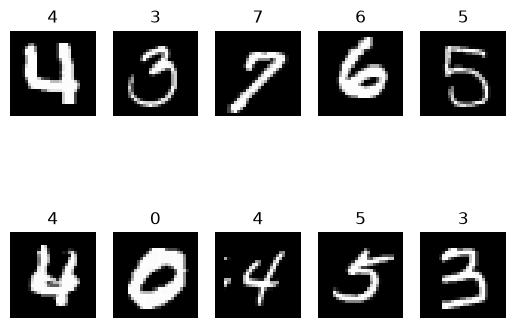

In [20]:
fig, axes = plt.subplots(2,5)
for i, ax in enumerate(axes.flat):
    ax.imshow(image[i].squeeze(), cmap = "gray")
    ax.set_title(label[i].item())
    ax.axis("off")

# Logistic Regression

Logistic regression is a supervised machine learning algorithm used for classification, predicting the probability of an event (e.g., yes/no) rather than continuous numbers. It models data using an S-shaped sigmoid function, mapping inputs to probabilities between 0 and 1.

In [22]:
class LogisticRegression (nn.Module):
    def __init__(self):
        # super().__init__(): Triggers the constructor of the parent class (nn.Module).
        # It sets up internal PyTorch registries necessary for tracking weights, biases, and submodules.
        super().__init__()
        #self.linear = nn.Linear(...): Registers a fully connected (dense) layer as an attribute of the class.
        # 28*28: Sets the input feature size to 784, matching the total pixels of a flattened 28 × 28 
        # 10: Sets the output size to 10, creating one raw score (logit) for each potential target class.
        self.linear = nn.Linear(28*28, 10) 

    def forward(self,x):
        x = x.view (-1, 28*28)
        return self.linear(x)